# Chapter 5. 회귀

## 01. 회귀 소개

여러개의 독립변수와 한 개의 종속 변수 간의 상관관계를 모델링하는 기법을 통칭
Y:종속변수,X:독립변수(=피처),W회귀계수

- 머신러닝에서 회귀 예측의 핵심:피처와 결정값 데이터 기반에서 학습을 통해 최적의 회귀계수를 찾는 것

- 회귀계수가 선형/선형x -> 선형회귀/비선형회귀

- 독립변수 개수 한개/여러개 -> 단일회귀/다중회귀

지도학습 1) 분류 - 예측값이 카테고리와 같은 이산형 클래스값
        2) 회귀 - 연속형 숫자값

- 선형회귀: 과적합 문제 해결하기 위해 회귀계수에 패널티값을 적용하는 것
ex. 로지스틱회귀,라쏘,릿지,엘라스틱넷

## 02. 단순 선형 회귀를 통한 회귀 이해

실제값 <-> 회귀모델 : 오류=잔차

최적의 회귀 모델 만든다 = 전체 데이터의 잔차 합이최소가 되는 모델을 만든다 & 오류 값 합이 최소가 됨 

오류합 계산  RSS=E^2

RSS는 비용함수라고도 불림

## 03. 비용 최소화하기 - 경사 하강법

비용함수가 최소화되는 w파라미터 구하는 법?

w파라미터 개수가 많으면 고차원 방정식 동원해도 해결어려움

- 경사하강법 : 고차원 방정식에 대한 문제 해결, RSS최소화함

점진적으로 반복적인 계산을 통해 w파라미터 값을 업데이트하면서 오류값이 최소가 되는 W파라미터를 구하는 방식

오류값이 더이상 작아지지 않으면 그 오류값을 최소비용으로 판단하고 w값을 최적 파라미터로 변환

어떻게 하면 오류 작아지는 방향으로 w값 보정??

- 미분한 1차함수 기울기가 덩이상 감소하지 않는 지점

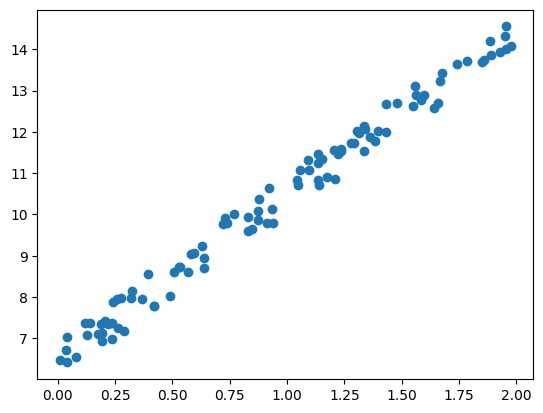

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
X=2*np.random.rand(100,1)
y=6+ 4*X+np.random.rand(100,1)

plt.scatter(X,y)

y=4x+6중심으로 무작위로 펼쳐짐

- 비용함수

In [7]:
def get_cost(y,y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

- 경사하강법

gradient_descent():w1,w0을 모두 0으로 초기화 ->iters개수만큼 반복하며 w1,w0을 업데이트함

In [9]:
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
    N=len(y)
    w1_update=np.zeros_like(w1)
    w0_update=np.zeros_like(w0)
    y_pred=np.dot(X,w1.T)+w0
    diff=y-y_pred

    w0_factors=np.ones((N,1))

    w1_update=-(2/N)*learning_rate*(np.dot(X.T,diff))
    w0_update=-(2/N)*learning_rate*(np.dot(w0_factors.T,diff))

    return w1_update,w0_update

- gradient_descent_steps()함수

In [12]:
def gradient_descent_steps(X,y,iters=10000):
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    for ind in range(iters):
        w1_update,w0_update=get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update
    return w1,w0

In [13]:
def get_cost(y,y_pred):
    N=len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost

w1,w0 = gradient_descent_steps(X,y,iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0],w0[0,0]))
y_pred=w1[0,0]*X+w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1:4.028 w0:6.490
Gradient Descent Total Cost:0.0775


- y_pred의 회귀선

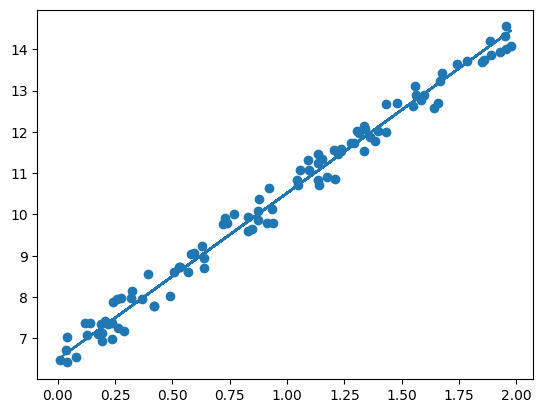

In [14]:
plt.scatter(X,y)
plt.plot(X,y_pred)

- 확률적 경사하강법

In [19]:
def stochastic_gradient_descent_steps(X,y,batch_size=10,iters=1000):
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    for ind in range(iters):
        np.random.seed(ind)
        stochastic_random_index=np.random.permutation(X.shape[0])
        sample_X=X[stochastic_random_index[0:batch_size]]
        sample_y=y[stochastic_random_index[0:batch_size]]
        w1_update,w0_update=get_weight_updates(w1,w0,sample_X,sample_y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update
    return w1,w0

In [20]:
w1,w0=stochastic_gradient_descent_steps(X,y,iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred=w1[0,0]*X+w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1: 4.031 w0: 6.486
Stochastic Gradient Descent Total Cost:0.0777


## 04. 사이킷런을 이용한 보스턴 주택 가격 예측

### lindear regression 클래스 - Ordinary Least Squares

RSS를 최소화해 OLS추정방식으로 구현한 클래스 x,y배열 받으면 회귀계수 w를 coef_속성에 저장함

In [23]:
class sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=1)
# 최신버젼에서는 오류뜸,,,

SyntaxError: invalid syntax (227981742.py, line 1)

- coef_: 회귀계수가 배열형태로 저장되는 속성
- intercept_:intercept값

OLS기반 회귀계수 계산은 입력 피처의 독립성에 많은 영향을 받음
피처 간 상관관계에 매우 높은 경우 분산이 커져 오류에 민감해짐(->다중공산성)

상관관계가 높은피처 많을 경우 공산성 문제 있다면 PCA를 통해 차원 축소 하는 것도 고려해볼 수 있음 

### 회귀평가지표

평가 지표는 실제값,회귀예측값의 차이값을 기반으로 한 지표가 중심. 절대값평균/제곱/제곱 후 루트 씌우는 평균값을 구함

- 사이킷런에서는 RMSE(실제값예측값차이제곱해평균한거 루트씌운것) 제공 x

- 음수가 될 수 x

### Linear Regression을 이용해 보스턴 주택 가격 회귀 구현

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
boston=load_boston()
bostonDF=pd.DataFrame(boston.data,columns=boston.feature_names)
bostonDF['Price']=boston.target
print('Boston 데이터셋 크기:',bostonDF.shape)
bostonDF.head()

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [27]:
# load_boston()이 삭제됨

In [28]:
#대체
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 데이터 로드
california = fetch_california_housing()
californiaDF = pd.DataFrame(california.data, columns=california.feature_names)
californiaDF['Price'] = california.target

print('California 데이터셋 크기:', californiaDF.shape)
californiaDF.head()


California 데이터셋 크기: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


- nan값은 없음

- 각 칼럼이 회귀 결과에 미치는 영향이 어느 정도 인지 시각화

- seaborn의 regplot()은 x,y의 산점도와 함께 선형회귀 직선 그림

NameError: name 'bostonDF' is not defined

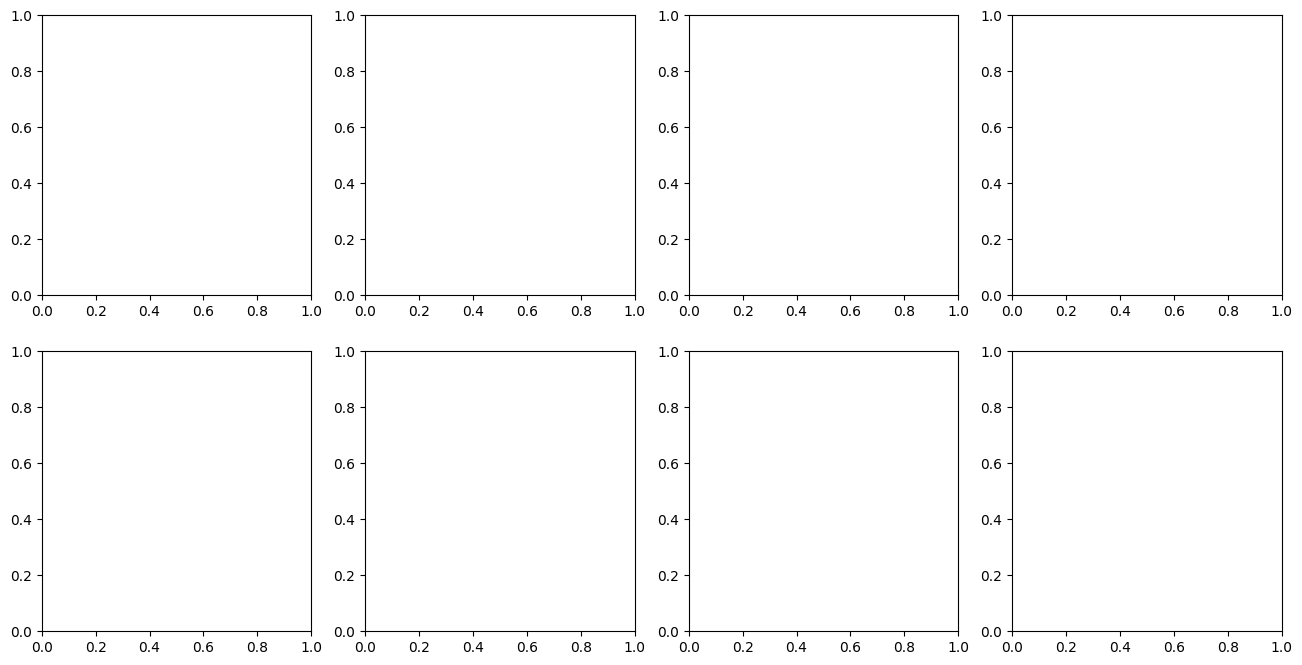

In [34]:
fig,axs=plt.subplots(figsize=(16,8),ncols=4,nrows=2)
lm_features=['RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD']
for i,feature in enumerate(lm_features):
    row=int(i/4)
    col=i%4
    sns.regplot(x=feature,y='PRICE',data=bostonDF,ax=axs[row][col])

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

y_target=bostonDF['PRICE']
X_data=bostonDF.drop(['PRICE'],axis=1,inplace=False)
X_train,X_test,y_train,y_test=train_test_split(X_data,y_target,test_size=0.3,random_state=156)

lr=LinearRegression()
lr.fit(X_train,y_train)
y_preds=lr.predict(X_test)
mse=mean_squared_error(y_test,y_preds)
rmse=np.sqrt(mse)

print('MSE:{0:.3f},RMSE:{1:.3f}'.format(r2_score(y_test,y_preds)))

NameError: name 'bostonDF' is not defined

In [35]:
print('절편값:',lr.intercept_)
print('회귀계수값:',np.round(lr.coef_,1)

SyntaxError: incomplete input (1654783219.py, line 2)

In [33]:
coeff=pd.Series(data=np.round(lr.coef_,1),index=X_data.columns)
coeff.sort_vales(ascending=False)

NameError: name 'lr' is not defined

In [37]:
from sklearn.model_selection import cross_val_score

y_target=bostonDF['PRICE']
X_data=bostonDF.drop(['PRICE'],axis=1,inplace=False)
lr=LinearRegression()

neg_mse_scores=cross_val_score(lr.X_data,y_target,scoring="neg_mean_squared_error",cv=5)
rmse_scores=np.sqrt(-1*neg_mse_scores)
avg_rmse=np.mean(rmse_scores)

print('5 folds 의 개별 negative mse scores:',np.round(neg_mse_scores,2))
print('5 folds의 개별 RMSE score:',np.round(rmse_scores,2))
print('5folds의 개별 평균 RMSE:{0:.3f}'.format(avg_rmse))

NameError: name 'bostonDF' is not defined

## 05. 다항 회귀와 과(대)적합/과소적합의 이해

### 다항회귀 이해

이전까진 독립,종속변수 관계가 일차방정식 형태

2,3차 방정식같은 다항회귀도 존재함

-> 비선형회귀x 다항회귀는 선형회귀다!`

polynomialFeatures클래스로 피처를 다항식 피처로 변환

In [40]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X=np.arange(4).reshape(2,2)
print('일차 단항식 계수 피처:\n',X)

poly=PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr=poly.transform(X)
print('변환된 2차 다항식계수 피처:\n',poly_ftr) 

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 다항식계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [41]:
def polynomial_func(X):
    y=1+2*X[:,0]+3*X[:,0]**2+4*X[:,1]**3
    return y
X=np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X)
y=polynomial_func(X)
print('삼차다항식 결정값:\n',y)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
삼차다항식 결정값:
 [  5 125]


In [42]:
#3차 다항식 변환
poly_ftr=PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature:\n',poly_ftr)

model=LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n',np.round(model.coef_,2))
print('Polynomial 회귀 Shape:',model.coef_.shape)

3차 다항식 계수 feature:
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape: (10,)


In [45]:
model = model.fit(X, y)  


from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2 * X[:, 0] + 3 * X[:, 0]**2 + 4 * X[:, 1]**3
    return y

# 입력 데이터
X = np.arange(4).reshape(2, 2)  # [[0, 1], [2, 3]]
y = polynomial_func(X)

# 파이프라인 생성 및 학습
model = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('linear', LinearRegression())
])

model = model.fit(X, y)

# 회귀계수 출력
print('Polynomial 회귀계수\n', np.round(model.named_steps['linear'].coef_, 2))


Polynomial 회귀계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 다항 회귀를 이용한 과소적합 및 과적합의 이해

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

def true_fun(X):
    return np.cos(1.5*np.pi*X)

np.random.seed(0)
n_samples=30
X=np.sort(np.random.rand(n_samples))

y=true_fun(X)+np.random.randn(n_samples)*0.1


Degree 1 회귀계수는 [-1.9]
Degree 1 MSE는 3.47e-01

Degree 4 회귀계수는 [ 12.45 -36.27  24.69  -0.49]
Degree 4 MSE는 1.25e-01

Degree 15 회귀계수는 [ 2.86300000e+01 -7.14910000e+02  1.34899500e+04 -1.66215100e+05
  1.35886047e+06 -7.58872144e+06  2.97428698e+07 -8.35238292e+07
  1.70058618e+08 -2.51489065e+08  2.67431930e+08 -1.99244080e+08
  9.87026411e+07 -2.91980557e+07  3.90224420e+06]
Degree 15 MSE는 6.18e+04


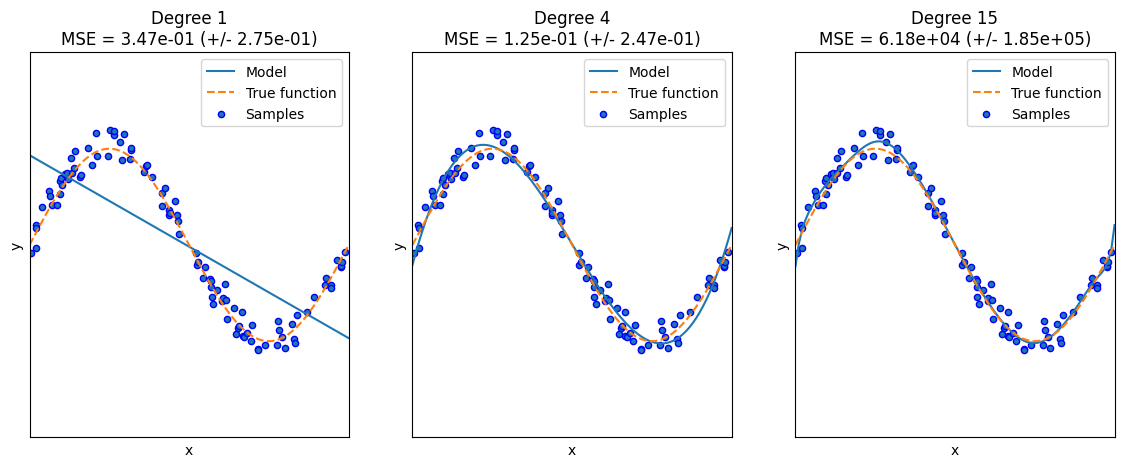

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

np.random.seed(0)
X = np.sort(np.random.rand(100, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel() + np.random.randn(100) * 0.1


def true_fun(X):
    return np.sin(2 * np.pi * X)

plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])

    pipeline.fit(X, y)
    scores = cross_val_score(pipeline, X, y, scoring="neg_mean_squared_error", cv=10)
    coefficients = pipeline.named_steps['linear_regression'].coef_

    print('\nDegree {} 회귀계수는 {}'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {} MSE는 {:.2e}'.format(degrees[i], -np.mean(scores)))

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), "--", label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e} (+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

plt.show()


### 편향-분산 트레이드오프

머신러닝이 극복해야할 가장 중요한 이슈중하나

편향이 높으면 분산 낮아짐(과소적합), 분산이 높으면 편향 낮아짐(과적함)

전체 오류가 가장 낮아지는 지점: 골디락스